Number of good V points: 36


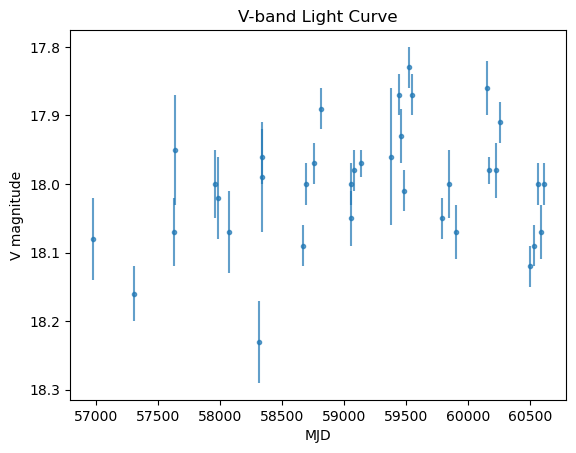

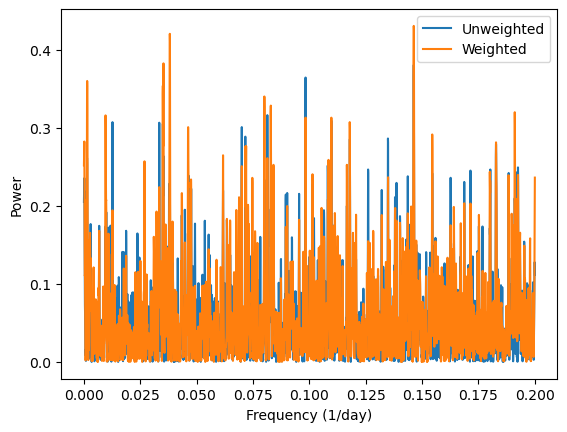

Best period (days): 6.834997771473453


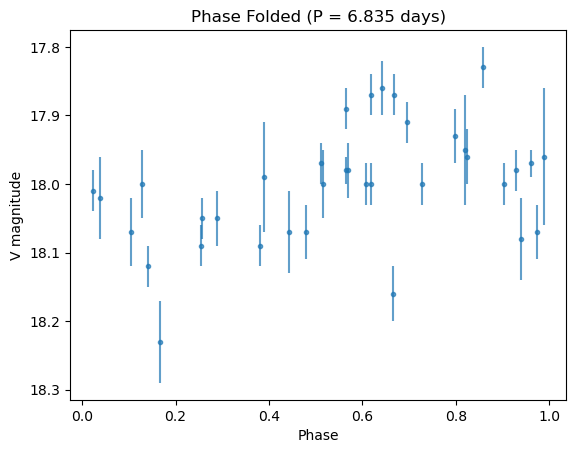

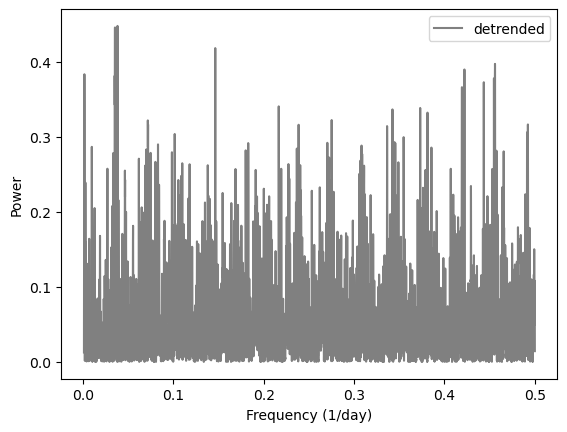

False Alarm Probability: 0.015241856165712999
Phase-folded amplitude (mag): 0.26250000000000284
Phase 0–0.5 mean: 18.066153846153846 std: 0.060068993862629844 N: 13
Phase 0.5–1.0 mean: 17.96608695652174 std: 0.07417600282493698 N: 23
Mean difference: 0.10006688963210664
Expected uncertainty: 0.022732821047497423
Significance (~sigma): 4.40186853285957


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.timeseries import LombScargle

filename = "M31-004621.08.tab.txt"

data = np.genfromtxt(
    filename,
    skip_header=1,
    dtype=str
)

mjd = data[:, 0].astype(float)

V_mag_raw = data[:, 1]
V_err_raw = data[:, 2]

valid_mag = V_mag_raw != "--.---"

valid_err = V_err_raw != "-.---"

mask = valid_mag & valid_err

mjd = mjd[mask]
V_mag = V_mag_raw[mask].astype(float)
V_err = V_err_raw[mask].astype(float)

print("Number of good V points:", len(V_mag))

plt.figure()
plt.errorbar(mjd, V_mag, yerr=V_err, fmt='.', alpha=0.7)
plt.gca().invert_yaxis()
plt.xlabel("MJD")
plt.ylabel("V magnitude")
plt.title("V-band Light Curve")
plt.show()


min_freq = 0.0001   #long timescale
max_freq = 0.2      #shorter timescale


ls_unweighted = LombScargle(mjd, V_mag)
frequency, power_unweighted = ls_unweighted.autopower(
    minimum_frequency=min_freq,
    maximum_frequency=max_freq
)

ls_weighted = LombScargle(mjd, V_mag, dy=V_err)
power_weighted = ls_weighted.power(frequency)

plt.figure()
plt.plot(frequency, power_unweighted, label="Unweighted")
plt.plot(frequency, power_weighted, label="Weighted")
plt.xlabel("Frequency (1/day)")
plt.ylabel("Power")
plt.legend()
plt.show()


best_freq = frequency[np.argmax(power_weighted)]
best_period = 1 / best_freq

print("Best period (days):", best_period)


phase = (mjd % best_period) / best_period

plt.figure()
plt.errorbar(phase, V_mag, yerr=V_err, fmt='.', alpha=0.7)
plt.gca().invert_yaxis()
plt.xlabel("Phase")
plt.ylabel("V magnitude")
plt.title(f"Phase Folded (P = {best_period:.3f} days)")
plt.show()


from scipy.signal import detrend

V_detrended = detrend(V_mag)

ls = LombScargle(mjd, V_detrended, dy=V_err)
frequency, power = ls.autopower(minimum_frequency=0.001, maximum_frequency=0.5)

plt.figure()
plt.plot(frequency, power, label="detrended", color='grey')
plt.xlabel("Frequency (1/day)")
plt.ylabel("Power")
plt.legend()
plt.show()

best_power = np.max(power)
fap = ls.false_alarm_probability(best_power)
print("False Alarm Probability:", fap)


test_period = best_period   

phase = (mjd % test_period) / test_period

idx = np.argsort(phase)
phase_sorted = phase[idx]
mag_sorted = V_mag[idx]

amp_phase = np.percentile(mag_sorted, 95) - np.percentile(mag_sorted, 5)
print("Phase-folded amplitude (mag):", amp_phase)

mask1 = (phase >= 0.0) & (phase < 0.5)
mask2 = (phase >= 0.5) & (phase < 1.0)

mean1 = np.mean(V_mag[mask1])
mean2 = np.mean(V_mag[mask2])

std1 = np.std(V_mag[mask1])
std2 = np.std(V_mag[mask2])

n1 = np.sum(mask1)
n2 = np.sum(mask2)

print("Phase 0–0.5 mean:", mean1, "std:", std1, "N:", n1)
print("Phase 0.5–1.0 mean:", mean2, "std:", std2, "N:", n2)

diff = abs(mean1 - mean2)
noise = np.sqrt(std1**2/n1 + std2**2/n2)

print("Mean difference:", diff)
print("Expected uncertainty:", noise)
print("Significance (~sigma):", diff / noise)

In [2]:
power = power_weighted
sorted_indices = np.argsort(power)[::-1]

top_freqs = []
top_periods = []

for idx in sorted_indices:
    freq = frequency[idx]
    period = 1 / freq
    
    if period > 5:
        top_freqs.append(freq)
        top_periods.append(period)
    
    if len(top_periods) == 3:
        break

print("\nTop 3 periods (days):")
for i, p in enumerate(top_periods):
    print(f"Peak {i+1}: {p:.3f} days")


Top 3 periods (days):
Peak 1: 6.793 days
Peak 2: 6.791 days
Peak 3: 25.599 days


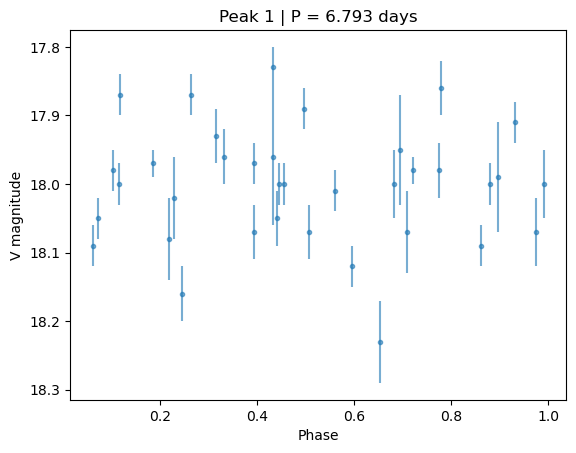

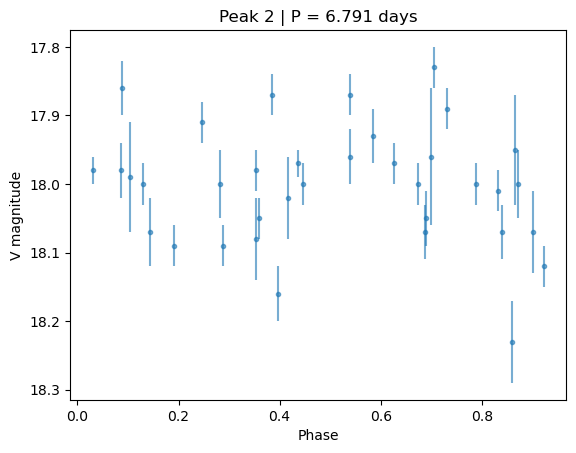

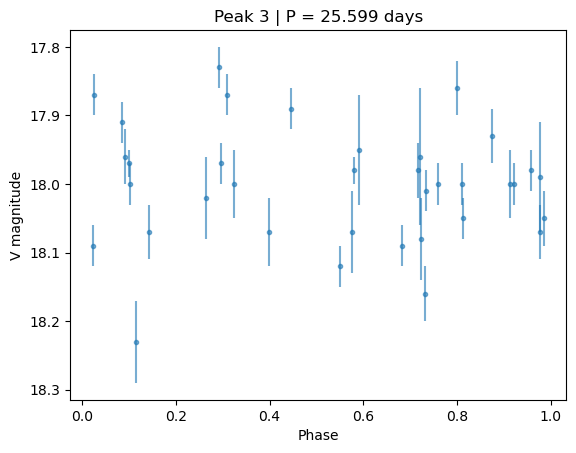

In [3]:
def phase_plot(mjd, mag, err, period, label):
    phase = (mjd % period) / period
    
    plt.figure()
    plt.errorbar(phase, mag, yerr=err, fmt='.', alpha=0.6)
    plt.gca().invert_yaxis()
    plt.xlabel("Phase")
    plt.ylabel("V magnitude")
    plt.title(f"{label} | P = {period:.3f} days")
    plt.show()

for i, period in enumerate(top_periods):
    phase_plot(mjd, V_mag, V_err, period, f"Peak {i+1}")